## Generacion de señales

In [ ]:
#!pip install pandas
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import neurokit2 as nk
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal
from scipy.stats import kurtosis, skew, entropy
import pandas as pd

## Prueba de señales simuladas con diferente patron

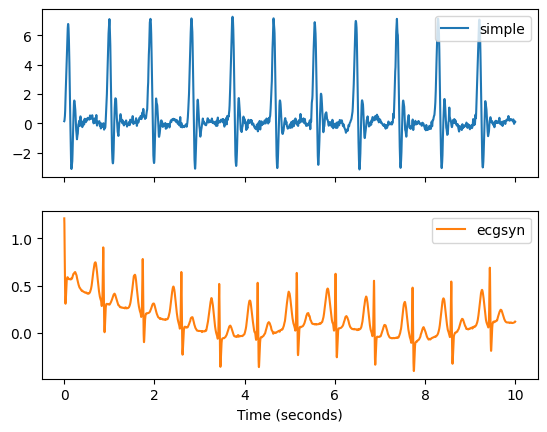

In [ ]:
# Simulate ECG signals using different methods
fs =1000  # Sampling frequency in Hz

# Normal parameters (used by default)
# ===================================
# t, the starting position along the circle of each interval in radius
ti = np.array((-70, -15, 0, 15, 100))
# a, the amplitude of each spike
ai = np.array((1.2, -5, 30, -7.5, 0.75))
# b, the width of each spike
bi = np.array((0.25, 0.1, 0.1, 0.1, 0.4))


# Add noise
# ===============
ti = np.random.normal(ti, np.ones(5) * 3)
ai = np.random.normal(ai, np.abs(ai / 5))
bi = np.random.normal(bi, np.abs(bi / 5))


# Method "simple" uses a basic sine wave approximation
# Method "ecgsyn" uses a more complex synthetic ECG generation
ecg1 = nk.ecg_simulate(duration=10, method="simple", random_state_distort= "legacy",ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=0.05)
ecg2 = nk.ecg_simulate(duration=10, method="ecgsyn", ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=0.01)

# Visualize result
nk.signal_plot([ecg1, ecg2], labels=["simple", "ecgsyn"], subplots=True, sampling_rate=fs)

### Funciones para extraer caracteristicas

In [ ]:
def extract_features(x: np.ndarray, bins: int = 50) -> dict:
    """
    Extrae características básicas de un vector 1D.
    """
    feats = {
        'mean': np.mean(x),
        'median': np.median(x),
        'std': np.std(x, ddof=0),
        'rms': np.sqrt(np.mean(x**2)),
        'energy': np.sum(x**2),
        'skewness': skew(x),
        'kurtosis': kurtosis(x),
    }
    # Entropía de Shannon a partir de histograma
    hist, _ = np.histogram(x, bins=bins, density=True)
    hist = hist[hist > 0]
    feats['entropy'] = entropy(hist)
    return feats

def extract_features_matrix(X: np.ndarray, axis: int = 1, bins: int = 50) -> pd.DataFrame:
    """
    Extrae características de cada serie en una matriz X de forma (n_samples, n_signals)
    o (n_signals, n_samples), según axis:
      - axis=0: cada columna es una señal
      - axis=1: cada fila es una señal
    Devuelve un DataFrame con una fila por señal y columnas las características.
    """
    # Transponer si las señales vienen por filas
    if axis == 1:
        X = X.T
    n_signals = X.shape[1]
    # Recorrer cada señal
    features_list = []
    for i in range(n_signals):
        feats = extract_features(X[:, i], bins=bins)
        feats['signal_index'] = i
        features_list.append(feats)
    df = pd.DataFrame(features_list)
    # Opcional: poner signal_index como índice
    df.set_index('signal_index', inplace=True)
    return df

In [ ]:
ecg_sim1 = []
for i in range(2):
    ecg_sim1.append(nk.ecg_simulate(duration=10, method="simple", random_state_distort= "legacy",ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=0.05))

ecg_sim1_array = np.array(ecg_sim1)
ecg_sim1_array

array([[0.20318302, 0.20967821, 0.22809925, ..., 0.1150302 , 0.10808579,
        0.10550027],
       [0.81012921, 0.80017196, 0.77323892, ..., 0.02045775, 0.02137441,
        0.02167049]], shape=(2, 10000))

In [ ]:
extract_features_matrix(ecg_sim1_array, axis=1, bins=60)

,mean,median,std,rms,energy,skewness,kurtosis,entropy
signal_index,,,,,,,,
0,0.475471,0.060965,1.744452,1.808089,32691.870264,2.033678,4.954336,2.868057
1,0.435553,-0.008821,1.776092,1.828717,33442.076625,2.078527,4.959079,2.836634


In [ ]:
def gen_signal_simultated_ecg(n=100):
    # Simulate ECG signals using different methods
    fs =1000  # Sampling frequency in Hz

    # Normal parameters (used by default)
    # ===================================
    # t, the starting position along the circle of each interval in radius
    ti = np.array((-70, -15, 0, 15, 100))
    # a, the amplitude of each spike
    ai = np.array((1.2, -5, 30, -7.5, 0.75))
    # b, the width of each spike
    bi = np.array((0.25, 0.1, 0.1, 0.1, 0.4))


    # Add noise
    # ===============
    ti = np.random.normal(ti, np.ones(5) * 3)
    ai = np.random.normal(ai, np.abs(ai / 5))
    bi = np.random.normal(bi, np.abs(bi / 5))


    # Method "simple" uses a basic sine wave approximation
    # Method "ecgsyn" uses a more complex synthetic ECG generation
    ecg_sim1 = []
    for i in range(n):
        ecg_sim1.append(nk.ecg_simulate(duration=10, method="simple", random_state_distort= "legacy",ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=0.05))

    ecg_sim2 = []
    for i in range(n):
        ecg_sim2.append(nk.ecg_simulate(duration=10, method="ecgsyn", ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=0.01))

    ecg_sim1_array = np.array(ecg_sim1)
    ecg_sim2_array = np.array(ecg_sim2)

    df_feats1 = extract_features_matrix(ecg_sim1_array, axis=1, bins=60)
    df_feats2 = extract_features_matrix(ecg_sim2_array, axis=1, bins=60)

    df_feats1["label"] = "simple"
    df_feats2["label"] = "ecgsyn"

    df_final = pd.concat([df_feats1, df_feats2], axis=0, ignore_index=True)

    return df_final

    #ecg2 = nk.ecg_simulate(duration=10, method="ecgsyn", ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=0.01)
    # Visualize result
    #nk.signal_plot([ecg1, ecg2], labels=["simple", "ecgsyn"], subplots=True, sampling_rate=fs)
    #return nk.ecg_simulate(duration=10, method=method, ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=noise)

In [ ]:
signal_gen = gen_signal_simultated_ecg(n = 100)

In [ ]:
signal_gen.head()

,mean,median,std,rms,energy,skewness,kurtosis,entropy,label
0,0.489877,0.067675,1.770880,1.837388,33759.937926,2.053693,5.060743,2.814066,simple
1,0.464181,0.047727,1.771748,1.831545,33545.561856,2.077690,4.966414,2.843319,simple
2,0.489052,0.048590,1.768861,1.835222,33680.396312,2.095819,4.995634,2.881508,simple
3,0.479552,0.051948,1.773874,1.837552,33765.982297,2.055468,5.005011,2.764904,simple
4,0.469559,0.046094,1.758757,1.820360,33137.119267,2.079959,5.013061,2.841504,simple


In [ ]:
signal_gen.tail()

,mean,median,std,rms,energy,skewness,kurtosis,entropy,label
195,0.150320,0.118813,0.194555,0.245861,604.475841,2.296222,8.516681,3.062105,ecgsyn
196,0.180180,0.145858,0.198477,0.268063,718.579915,2.328535,8.718619,3.012639,ecgsyn
197,0.150974,0.113166,0.200179,0.250729,628.648210,2.377511,8.959894,3.005553,ecgsyn
198,0.161313,0.128038,0.198965,0.256142,656.088043,2.332532,8.775574,3.047588,ecgsyn
199,0.179779,0.149443,0.198168,0.267565,715.909966,2.226008,8.264798,3.088349,ecgsyn


## Aplicar un escalamiento

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# Seleccionamos solo las columnas numéricas
signal_gen_num = signal_gen.drop(columns=['label']).copy()

# Instanciamos y aplicamos StandardScaler
scaler = RobustScaler()
signal_gen_scaled = scaler.fit_transform(signal_gen_num)

# Convertimos a DataFrame y agregamos la columna 'label'
signal_gen_scaled_df = pd.DataFrame(signal_gen_scaled, columns=signal_gen_num.columns)
signal_gen_scaled_df['label'] = signal_gen['label'].values

signal_gen_scaled_df.head()

,mean,median,std,rms,energy,skewness,kurtosis,entropy,label
0,0.531740,-0.407986,0.513359,0.506310,0.526045,-0.313484,-0.364358,-0.538977,simple
1,0.449321,-0.641432,0.513912,0.502603,0.519536,-0.217089,-0.389973,-0.411542,simple
2,0.529096,-0.631334,0.512074,0.504936,0.523630,-0.144270,-0.382038,-0.245177,simple
3,0.498623,-0.592042,0.515265,0.506414,0.526228,-0.306351,-0.379492,-0.753139,simple
4,0.466571,-0.660544,0.505643,0.495508,0.507135,-0.207977,-0.377306,-0.419447,simple


## Verificar separabilidad con PCA y 2 caractersiticas


=== Resultados PCA (2 dimensiones) ===
          PC1       PC2 Signal_Type
0   -1.354876  0.241257      simple
1   -1.336153  0.040134      simple
2   -1.275873  0.053034      simple
3   -1.487808  0.051180      simple
4   -1.334383  0.018828      simple
..        ...       ...         ...
195  1.366710 -0.027063      ecgsyn
196  1.426744  0.067088      ecgsyn
197  1.408441 -0.358375      ecgsyn
198  1.441784 -0.063911      ecgsyn
199  1.372553  0.455971      ecgsyn

[200 rows x 3 columns]


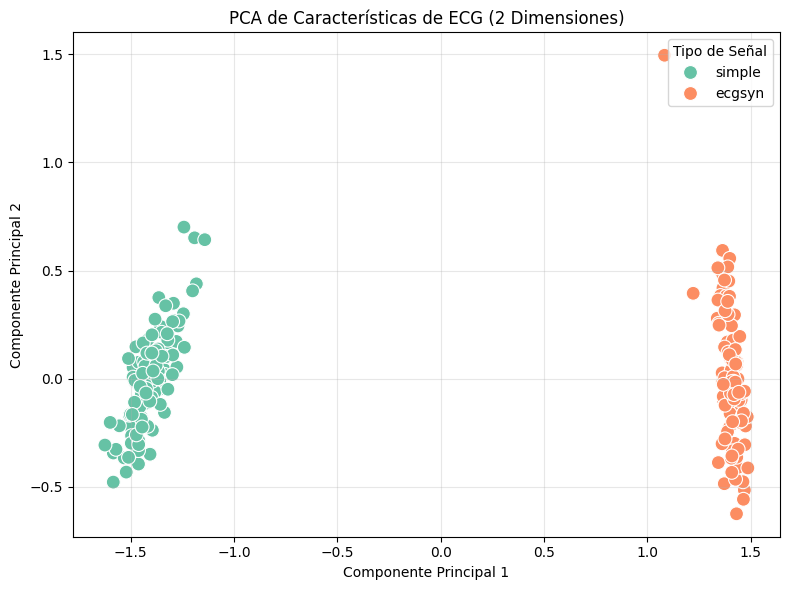

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

# 3.1) Preparamos los datos numéricos para PCA (quitamos la columna Signal_Type)
pca_input = signal_gen_scaled_df.drop(columns=['label']).copy()

# 3.1.1) Rellenar NaNs (por seguridad). Aquí se llenan con la media de cada columna.
pca_input = pca_input.fillna(pca_input.mean())

# 3.2) Instanciar y entrenar PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_input)  # devuelve matrix (n_signals × 2)

# 3.3) Armamos un DataFrame para graficar
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['Signal_Type'] = signal_gen_scaled_df['label']

print("\n=== Resultados PCA (2 dimensiones) ===")
print(pca_df)


# ------------------------------------------------------
# 4) GRAFICAR RESULTADOS DEL PCA
# ------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Signal_Type',
    data=pca_df,
    s=100,
    palette="Set2"
)
plt.title('PCA de Características de ECG (2 Dimensiones)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(alpha=0.3)
plt.legend(title='Tipo de Señal')
plt.tight_layout()
plt.show()

## CLasificador

In [ ]:
label2num = {"simple": 0, "ecgsyn": 1}
num2label = {v: k for k, v in label2num.items()}
signal_gen_scaled_df.replace(label2num, inplace=True)

signal_gen_scaled_df.head()

,mean,median,std,rms,energy,skewness,kurtosis,entropy,label
0,0.531740,-0.407986,0.513359,0.506310,0.526045,-0.313484,-0.364358,-0.538977,0
1,0.449321,-0.641432,0.513912,0.502603,0.519536,-0.217089,-0.389973,-0.411542,0
2,0.529096,-0.631334,0.512074,0.504936,0.523630,-0.144270,-0.382038,-0.245177,0
3,0.498623,-0.592042,0.515265,0.506414,0.526228,-0.306351,-0.379492,-0.753139,0
4,0.466571,-0.660544,0.505643,0.495508,0.507135,-0.207977,-0.377306,-0.419447,0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Preparamos los datos
X = signal_gen_scaled_df.drop(columns=['label'])
y = signal_gen_scaled_df['label']

# 2. Dividimos en train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #, stratify=y

# 3. Entrenamos un modelo Random Forest
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Predicciones y evaluación
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[21  0]
 [ 0 19]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        19

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



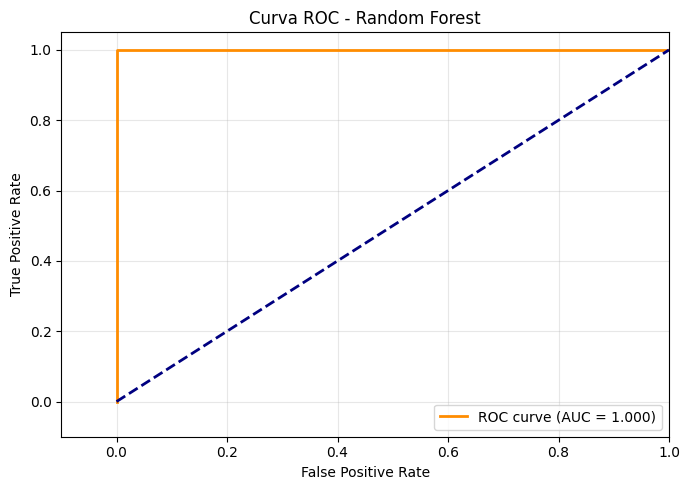

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelBinarizer

import matplotlib.pyplot as plt

# Binarizar las etiquetas para clasificación binaria
lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_pred_prob = clf.predict_proba(X_test)[:, 1]  # Probabilidad para la clase 'ecgsyn' (o la segunda clase)

# Calcular curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test_bin, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Graficar curva ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.1, 1.0])
plt.ylim([-0.1, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Random Forest')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Creando un pipeline

## Prueba del modelo

In [ ]:
signal_gen_scaled_df

,mean,median,std,rms,energy,skewness,kurtosis,entropy,label
0,0.531740,-0.407986,0.513359,0.506310,0.526045,-0.313484,-0.364358,-0.538977,0
1,0.449321,-0.641432,0.513912,0.502603,0.519536,-0.217089,-0.389973,-0.411542,0
2,0.529096,-0.631334,0.512074,0.504936,0.523630,-0.144270,-0.382038,-0.245177,0
3,0.498623,-0.592042,0.515265,0.506414,0.526228,-0.306351,-0.379492,-0.753139,0
4,0.466571,-0.660544,0.505643,0.495508,0.507135,-0.207977,-0.377306,-0.419447,0
...,...,...,...,...,...,...,...,...,...
195,-0.557379,0.190466,-0.490024,-0.503301,-0.480625,0.660719,0.574116,0.541559,1
196,-0.461604,0.506968,-0.487527,-0.489217,-0.477161,0.790514,0.628953,0.326067,1
197,-0.555281,0.124375,-0.486444,-0.500213,-0.479891,0.987245,0.694472,0.295201,1
198,-0.522119,0.298420,-0.487217,-0.496779,-0.479058,0.806571,0.644420,0.478317,1


In [ ]:
signal_pos = 50
signal_features = signal_gen_scaled_df.loc[signal_pos,:].to_numpy()[:-1].astype(float)
signal_label = signal_gen_scaled_df.loc[signal_pos, 'label']

print("\n=== Características de la señal en la posición", signal_features, "===", "label: ",num2label[int(signal_label)])


=== Características de la señal en la posición [ 0.50450024 -0.60273481  0.51230754  0.50387372  0.52176454 -0.12876238
 -0.36043919 -0.40037435] === label:  simple


In [ ]:
res = clf.predict(signal_features.reshape(1, -1))  # Aseguramos que sea 2D

print("Predicción de la señal :", num2label[int(res)])

Predicción de la señal : simple


## Crear pipeline

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
import numpy as np

# 1. Feature extraction transformer
class ECGFeatureExtractor(BaseEstimator, TransformerMixin):
    def __init__(self, bins=60):
        self.bins = bins

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # X: array-like, shape (n_signals, n_samples)
        # If 1D, reshape to (1, -1)
        if X.ndim == 1:
            X = X.reshape(1, -1)
        feats_df = extract_features_matrix(X, axis=1, bins=self.bins)
        return feats_df.values

# 2. Pipeline definition
ecg_pipeline = Pipeline([
    ('features', ECGFeatureExtractor(bins=50)),
    ('scaler', scaler),  # scaler already fitted
    ('clf', clf)         # clf already fitted
])

# Ejemplo de uso:
# signal: array 1D (señal cruda) o 2D (varias señales, cada fila una señal)
#pred = ecg_pipeline.predict()  # Aseguramos que sea 2D
#pred = lb.inverse_transform(pred)  # Convertir de vuelta a etiquetas originales
#print("Predicción de la señal:", pred)

### Creamos una señales

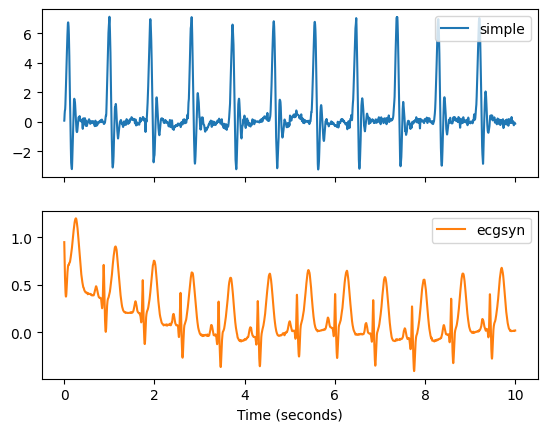

In [ ]:
# Simulate ECG signals using different methods
fs =1000  # Sampling frequency in Hz

# Normal parameters (used by default)
# ===================================
# t, the starting position along the circle of each interval in radius
ti = np.array((-70, -15, 0, 15, 100))
# a, the amplitude of each spike
ai = np.array((1.2, -5, 30, -7.5, 0.75))
# b, the width of each spike
bi = np.array((0.25, 0.1, 0.1, 0.1, 0.4))


# Add noise
# ===============
ti = np.random.normal(ti, np.ones(5) * 3)
ai = np.random.normal(ai, np.abs(ai / 5))
bi = np.random.normal(bi, np.abs(bi / 5))


# Method "simple" uses a basic sine wave approximation
# Method "ecgsyn" uses a more complex synthetic ECG generation
ecg1 = nk.ecg_simulate(duration=10, method="simple", random_state_distort= "legacy",ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=0.05)
ecg2 = nk.ecg_simulate(duration=10, method="ecgsyn", ti=ti, ai=ai, bi=bi, sampling_rate=fs, noise=0.01)

# Visualize result
nk.signal_plot([ecg1, ecg2], labels=["simple", "ecgsyn"], subplots=True, sampling_rate=fs)

In [ ]:
pred = ecg_pipeline.predict(ecg1)  # Aseguramos que sea 2D
print("Predicción de la señal ecg1:", num2label[int(pred)])

pred = ecg_pipeline.predict(ecg2)  # Aseguramos que sea 2D
print("Predicción de la señal ecg2:", num2label[int(pred)])

Predicción de la señal ecg1: simple
Predicción de la señal ecg2: ecgsyn
